<a href="https://colab.research.google.com/github/gustavomartinellidev/llm-evaluation-harness/blob/main/LLM_Evaluation_Harness_with_LangGraph_CV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proof of Concepct (PoC) with LangGraph**

### **Author:** [Gustavo Martinelli](https://www.linkedin.com/in/gustavomartinelli/)
### **Repository:** [github.com/gustavomartinellidev/llm-evaluation-harness](https://github.com/gustavomartinellidev/llm-evaluation-harness)

---

## **LLM Evaluation Harness with LangGraph**

---

### A multi-node state graph that benchmarks generative models in parallel, captures quality, latency, tokens and cost, and produces a structured decision memo with an adopt, watch or avoid recommendation.

### ⚠️ ℹ: You must add a Colab secret (🔑) named `OPENAI_API_KEY` with the `API KEY` value before using.

## **1) Install the OpenAI SDK (for the model listing cell) plus LangGraph and the LangChain integration**

In [ ]:
!pip install -q openai
!pip install -q langgraph langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 8.5 MB/s eta 0:00:00


## **2) Imports for the graph (LangGraph + LangChain OpenAI), Colab secrets, and inline Markdown rendering**

In [ ]:
import os, time, json, re
from typing import TypedDict, Annotated, List
from operator import add

from openai import OpenAI
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from IPython.display import Image, Markdown, display
from google.colab import userdata

## **3) Load the API key from Colab Secrets into an env var so the OpenAI SDK and LangChain find it**

In [ ]:
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
print("API key loaded ✓")

API key loaded ✓


## **4) List the GPT models this account can call, to pick the exact IDs for the harness below**

In [ ]:
client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])
for m in sorted(client.models.list().data, key=lambda x: x.id):
    if "gpt" in m.id.lower():
        print(m.id)

chatgpt-image-latest
gpt-3.5-turbo
gpt-3.5-turbo-0125
gpt-3.5-turbo-1106
gpt-3.5-turbo-16k
gpt-3.5-turbo-instruct
gpt-3.5-turbo-instruct-0914
gpt-4
gpt-4-0613
gpt-4-turbo
gpt-4-turbo-2024-04-09
gpt-4.1
gpt-4.1-2025-04-14
gpt-4.1-mini
gpt-4.1-mini-2025-04-14
gpt-4.1-nano
gpt-4.1-nano-2025-04-14
gpt-4o
gpt-4o-2024-05-13
gpt-4o-2024-08-06
gpt-4o-2024-11-20
gpt-4o-audio-preview
gpt-4o-audio-preview-2024-12-17
gpt-4o-audio-preview-2025-06-03
gpt-4o-mini
gpt-4o-mini-2024-07-18
gpt-4o-mini-audio-preview
gpt-4o-mini-audio-preview-2024-12-17
gpt-4o-mini-realtime-preview
gpt-4o-mini-realtime-preview-2024-12-17
gpt-4o-mini-search-preview
gpt-4o-mini-search-preview-2025-03-11
gpt-4o-mini-transcribe
gpt-4o-mini-transcribe-2025-03-20
gpt-4o-mini-transcribe-2025-12-15
gpt-4o-mini-tts
gpt-4o-mini-tts-2025-03-20
gpt-4o-mini-tts-2025-12-15
gpt-4o-realtime-preview
gpt-4o-realtime-preview-2024-12-17
gpt-4o-realtime-preview-2025-06-03
gpt-4o-search-preview
gpt-4o-search-preview-2025-03-11
gpt-4o-transcribe

## **5) Shared graph state, the OpenAI pricing table, and a cost helper used by the workers below**

> ## On May, 12th - for short content 👉 <272k tokens:
> ## gpt-5.4-nano I/O: 0.20/1.25
> ## gpt-5.4-mini I/O: 0.75/4.50
> ## gpt-5.4 I/O: 2.50/15.00

### Source: [Princing](https://developers.openai.com/api/docs/pricing?latest-pricing=standard)

In [ ]:
class EvaluationState(TypedDict):
    task: str
    models: List[str]
    model_name: str
    results: Annotated[List[dict], add]
    judge_evaluation: dict
    decision_memo: str

MODEL_PRICING = {
    "gpt-5.4-nano": {"input": 0.20, "output": 1.25},
    "gpt-5.4-mini": {"input": 0.75, "output": 4.50},
    "gpt-5.4":      {"input": 2.50, "output": 15.00},
}

def cost_per_272k_tokens_runs(model_name, input_tokens, output_tokens):
    p = MODEL_PRICING.get(model_name, {"input": 0, "output": 0})
    one_run = (input_tokens / 1_000_000) * p["input"] + (output_tokens / 1_000_000) * p["output"]
    return round(one_run * 1000, 4)

##**6) Graph nodes: fan-out dispatcher, worker (with retry on 429), judge, memo writer, error handler, and the router**

In [ ]:
def dispatch_models(state):
    """Fan-out: emit one Send per model — workers run in parallel."""
    return [
        Send("run_model", {"task": state["task"], "model_name": m})
        for m in state["models"]
    ]

def run_model(state):
    """Invoke one model with retry on rate-limit (429); capture quality, latency, tokens, cost."""
    model_name = state["model_name"]
    task = state["task"]
    max_retries = 3
    backoff = 4  # seconds

    for attempt in range(max_retries):
        try:
            llm = ChatOpenAI(model=model_name, temperature=0)
            t0 = time.time()
            response = llm.invoke(task)
            latency = round(time.time() - t0, 2)
            usage = response.usage_metadata or {}
            in_tok = usage.get("input_tokens", 0)
            out_tok = usage.get("output_tokens", 0)
            return {"results": [{
                "model": model_name,
                "status": "success",
                "output": response.content,
                "latency_seconds": latency,
                "input_tokens": in_tok,
                "output_tokens": out_tok,
                "cost_per_272k_tokens_runs_usd": cost_per_272k_tokens_runs(model_name, in_tok, out_tok),
                "retries": attempt,
            }]}
        except Exception as e:
            err_str = str(e)
            is_rate_limit = "429" in err_str or "rate_limit" in err_str.lower()
            if is_rate_limit and attempt < max_retries - 1:
                time.sleep(backoff * (2 ** attempt))  # 4s, 8s, 16s
                continue
            return {"results": [{
                "model": model_name,
                "status": "error",
                "error": err_str[:200],
                "retries": attempt,
            }]}

def judge_outputs(state):
    """LLM-as-judge: score each successful output on quality."""
    successes = [r for r in state["results"] if r["status"] == "success"]
    if not successes:
        return {"judge_evaluation": {"error": "no successful runs"}}

    prompt = f"You are evaluating LLM outputs for this task:\n{state['task']}\n\nOutputs:\n"
    for r in successes:
        prompt += f"\n--- {r['model']} ---\n{r['output']}\n"
    prompt += (
        "\nScore each model's output 1-10 on quality (accuracy, completeness, clarity).\n"
        "Return ONLY valid JSON in this format, no markdown fences:\n"
        '{"evaluations": [{"model": "...", "score": N, "rationale": "one sentence"}]}\n'
    )

    judge_llm = ChatOpenAI(model="gpt-5.4-mini", temperature=0)
    raw = judge_llm.invoke(prompt).content
    clean = re.sub(r"```(?:json)?|```", "", raw).strip()
    try:
        return {"judge_evaluation": json.loads(clean)}
    except json.JSONDecodeError:
        return {"judge_evaluation": {"raw": raw, "parse_error": True}}

def write_decision_memo(state):
    """Synthesize the comparison table, rationale, and recommendation as Markdown."""
    results = state["results"]
    je = state["judge_evaluation"]
    score_map = {e["model"]: e for e in je.get("evaluations", [])}

    md = f"# Decision Memo — LLM Evaluation\n\n**Task evaluated:** {state['task']}\n\n"
    md += "## Comparison Table\n\n"
    md += "| Model | Status | Latency (s) | Out tokens | Cost / <272k tokens runs (USD) | Quality |\n"
    md += "|---|---|---|---|---|---|\n"
    for r in results:
        if r["status"] == "success":
            q = score_map.get(r["model"], {}).get("score", "—")
            md += f"| `{r['model']}` | ✅ | {r['latency_seconds']} | {r['output_tokens']} | {r['cost_per_272k_tokens_runs_usd']} | {q}/10 |\n"
        else:
            err = (r.get("error", "?") or "?")[:50]
            md += f"| `{r['model']}` | ❌ {err} | — | — | — | — |\n"

    md += "\n## Quality Rationale\n\n"
    for model, e in score_map.items():
        md += f"- **`{model}`** ({e.get('score','?')}/10): {e.get('rationale','')}\n"

    successes = [r for r in results if r["status"] == "success"]
    if successes and score_map:
        ranked = sorted(
            successes,
            key=lambda r: (
                -score_map.get(r["model"], {}).get("score", 0),
                r["cost_per_272k_tokens_runs_usd"],
            ),
        )
        winner = ranked[0]
        md += "\n## Recommendation\n\n"
        md += f"**Adopt:** `{winner['model']}`\n\n"
        md += f"- Quality: {score_map.get(winner['model'],{}).get('score','?')}/10\n"
        md += f"- Latency: {winner['latency_seconds']}s\n"
        md += f"- Cost: USD {winner['cost_per_272k_tokens_runs_usd']} per <272k tokens runs\n"
        md += "\n*Recommendation rule: highest quality score; ties broken by lowest cost.*\n"

    return {"decision_memo": md}


def error_handler(state):
    return {"decision_memo": "# Decision Memo\n\nAll model runs failed. Investigate API access, quotas, or model names."}


def route_after_judge(state):
    return "error_handler" if state["judge_evaluation"].get("error") else "write_decision_memo"

##**7) Wire the nodes together, compile the graph, and render the diagram inline**

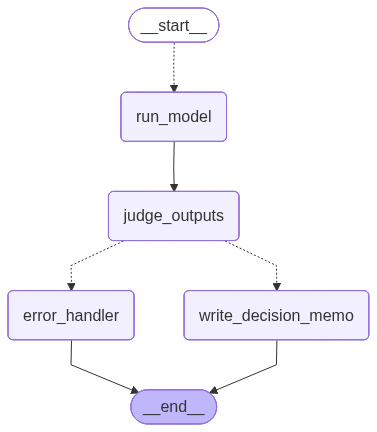

In [ ]:
builder = StateGraph(EvaluationState)

builder.add_node("run_model", run_model)
builder.add_node("judge_outputs", judge_outputs)
builder.add_node("write_decision_memo", write_decision_memo)
builder.add_node("error_handler", error_handler)

builder.add_conditional_edges(START, dispatch_models, ["run_model"])
builder.add_edge("run_model", "judge_outputs")
builder.add_conditional_edges("judge_outputs", route_after_judge, ["write_decision_memo", "error_handler"])
builder.add_edge("write_decision_memo", END)
builder.add_edge("error_handler", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

##**8) Invoke the graph with a sample task across three GPT tiers, then render the decision memo inline**

In [ ]:
result = graph.invoke({
    "task": (
        "In 3 sentences, explain how distributed payment systems handle "
        "currency conversion for cross-border transactions in emerging markets, "
        "including the role of FX spreads and intermediary banks."
    ),
    "models": ["gpt-5.4-nano", "gpt-5.4-mini", "gpt-5.4"],
    "results": [],
    "judge_evaluation": {},
    "decision_memo": "",
    "model_name": "",
})

display(Markdown(result["decision_memo"]))

# Decision Memo — LLM Evaluation

**Task evaluated:** In 3 sentences, explain how distributed payment systems handle currency conversion for cross-border transactions in emerging markets, including the role of FX spreads and intermediary banks.

## Comparison Table

| Model | Status | Latency (s) | Out tokens | Cost / <272k tokens runs (USD) | Quality |
|---|---|---|---|---|---|
| `gpt-5.4-nano` | ✅ | 2.43 | 128 | 0.1674 | 9/10 |
| `gpt-5.4-mini` | ✅ | 2.65 | 126 | 0.5948 | 8/10 |
| `gpt-5.4` | ✅ | 4.8 | 122 | 1.9225 | 9/10 |

## Quality Rationale

- **`gpt-5.4-nano`** (9/10): Accurate, complete, and clear, with a strong explanation of FX conversion, spreads, and intermediary banks; only slightly more detailed than necessary.
- **`gpt-5.4-mini`** (8/10): Mostly accurate and clear, but a bit less precise about how conversion occurs in distributed systems and less explicit about the mechanics of intermediary banks.
- **`gpt-5.4`** (9/10): Very accurate and complete for emerging markets, clearly covering routing, FX spreads, and intermediary banks, though it is slightly more verbose than required.

## Recommendation

**Adopt:** `gpt-5.4-nano`

- Quality: 9/10
- Latency: 2.43s
- Cost: USD 0.1674 per <272k tokens runs

*Recommendation rule: highest quality score; ties broken by lowest cost.*
